## Business Problem

A SaaS subscription company is experiencing customer churn.

Goal:
- Identify high-risk customer segments
- Quantify revenue impact
- Recommend actions to reduce churn in next 90 days

## Assumptions & Limitations

- The dataset provides only a static cross-sectional snapshot with no exact signup or churn event timestamps, making time-series analysis, cohort tracking, or true survival modeling impossible.
- Marketing spend, customer acquisition cost (CAC), and campaign attribution data are absent, preventing any LTV:CAC analysis or evaluation of acquisition channel effectiveness.
- The churn rate calculation carries **length bias**: longer-tenured customers are over-represented in the retained group, while newer customers have had less exposure time to churn, potentially understating true churn risk for recent sign-ups.
- The overall average MRR blends active and churned customers, which overstates current revenue health. Once churned, a customer contributes $0 MRR; including their historical MRR inflates the metric and gives a misleading view of the active revenue pipeline.
- Tenure-based cohorts are static and do not account for calendar time. Customers reaching the same tenure in different years experienced different product versions, pricing, and market conditions, which may distort cohort churn analysis.
- Revenue at Risk calculation assumes churned customers would continue paying their final MRR indefinitely, which may overstate the true loss by ignoring potential downgrades or usage fluctuations.
- Churn rate visualization by contract type does not show the underlying customer volume (count) per contract. A high churn rate on a small base can be visually misleading compared to a moderate rate on a large base.
- Tenure cohorts were explicitly binned into 12-month, 24-month, and 48-month intervals to align with standard B2B SaaS annual contract renewal cycles, rather than using statistical quantiles. This assumes churn behavior is tied to annual renewal milestones.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Initial Observations
- This data has zero null values.
- `TotalCharges` has object data type which needs conversion.

In [3]:
print(f"DataSet Shape is : {df.shape} \n")
print("Data quick info:")
df.info()
print("\nNull Count:")
df.isnull().sum()

DataSet Shape is : (7043, 21) 

Data quick info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

- **Observation:** TotalCharges is stored as an object. It must be coerced to a numeric type to calculate revenue metrics, which will expose any hidden empty strings as nulls.

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"Nulls after conversion: {df['TotalCharges'].isnull().sum()}")

Nulls after conversion: 11


In [5]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


- **Action**: Coerced TotalCharges to numeric. Found 11 nulls. Because these customers have a tenure of 0 (brand new signups), their total charges were filled with 0 rather than dropped, preserving new-user acquisition data.
- **Assumption**: Filled null TotalCharges with 0 assuming postpaid billing (no bill generated yet). Assumption breaks if prepaid (TotalCharges should equal MonthlyCharges).

In [6]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

## Data Summary & Validation

The `.describe()` output confirms a reasonable spread across all numeric columns with no obvious anomalies. MRR ranges from \\$18.25 to \\$118.75, LTV from \\$0 to \\$8,684.80, and MonthsSubscribed from 0 to 72 months, all within expected bounds for a telco/SaaS dataset.

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## SaaS Schema Mapping
**Action**: Mapped telco operational columns to standard SaaS business metrics to align analysis with executive terminology.

In [8]:
# renaming columns
rename_dict = {
    "MonthlyCharges":"MRR",
    "TotalCharges":"HistoricalRevenue",
    "tenure":"MonthsSubscribed"
}

df.rename(columns=rename_dict, inplace=True)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,MonthsSubscribed,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MRR,HistoricalRevenue,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# Fix the column name
df = df.rename(columns={"HistoricalRevenue": "LTV"})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,MonthsSubscribed,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MRR,LTV,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Business KPIs: 
- What is the current churn rate?
- overall Average MRR?
- Average MRR segmented by churn status?
- the average lifespan of a churned customer?

In [10]:
# current churn rate %
churn_rate = round((df['Churn'] == "Yes").mean() * 100, 2)

# Overall Average MRR
avg_mrr = round(df['MRR'].mean(), 2)

# Current revenue health (only active customers)
avg_mrr_active = round(df[df['Churn'] == 'No']['MRR'].mean(), 2)

# Avg MRR by churn
avg_mrr_by_churn = round(df.groupby('Churn')['MRR'].mean(),2)

# avg lifespan of churned customers
churned_avg_lifespan = round(df[df['Churn'] == 'Yes']['MonthsSubscribed'].mean(), 2)

print(f"Churn Rate: {churn_rate}%")
print(f"Overall Average MRR (incl. churned): ${avg_mrr}")
print(f"Active Customers Average MRR: ${avg_mrr_active}")
print("\nAverage MRR by Churn:")
print(avg_mrr_by_churn)
print(f"\nAverage Lifespan of Churned Customers: {churned_avg_lifespan} months")

Churn Rate: 26.54%
Overall Average MRR (incl. churned): $64.76
Active Customers Average MRR: $61.27

Average MRR by Churn:
Churn
No     61.27
Yes    74.44
Name: MRR, dtype: float64

Average Lifespan of Churned Customers: 17.98 months


## Key Findings

The overall churn rate stands at 26%. The average MRR across the entire customer base is \\$64.76. Notably, churned customers exhibit a higher average MRR of \\$74.44 compared to non-churned customers at \\$61.27. Additionally, churned customers remained active for an average of 18 months before churning.

### Churn Flag (to calculate churn rate of any segment easily)

In [11]:
df['Churn_Flag'] = df['Churn'].map({"Yes": 1, "No":0})

df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,MonthsSubscribed,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MRR,LTV,Churn,Churn_Flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1


## Segment Analysis: Where is the churn concentrated?
- What is the churn rate across different subscription types, payment methods, and internet service levels?

In [12]:
# Calculating churn rate across contract type, payment method and internet service
contract_type_churn = round(df.groupby('Contract')['Churn_Flag'].mean(), 2)
payment_method_churn = round(df.groupby('PaymentMethod')['Churn_Flag'].mean(), 2)
internet_service_churn = round(df.groupby('InternetService')['Churn_Flag'].mean(), 2)

print("Contract Types Churn Rate: \n", contract_type_churn)
print("\nPayment Method Churn Rate: \n", payment_method_churn)
print("\nInternet Service Churn Rate: \n", internet_service_churn)

Contract Types Churn Rate: 
 Contract
Month-to-month    0.43
One year          0.11
Two year          0.03
Name: Churn_Flag, dtype: float64

Payment Method Churn Rate: 
 PaymentMethod
Bank transfer (automatic)    0.17
Credit card (automatic)      0.15
Electronic check             0.45
Mailed check                 0.19
Name: Churn_Flag, dtype: float64

Internet Service Churn Rate: 
 InternetService
DSL            0.19
Fiber optic    0.42
No             0.07
Name: Churn_Flag, dtype: float64


### Key Findings
- Month-to-month contracts carry the highest churn risk (43%), compared to just 3% for two-year contracts. Fiber optic customers also show disproportionately high churn (42%), suggesting potential pricing or service-quality friction. Notably, customers paying via Electronic Check churn at 45%, significantly higher than automated credit card payments (15%), which may indicate higher rates of involuntary churn due to billing failures

## Revenue at Risk
What is the total Monthly Recurring Revenue (MRR) lost to churned customers, and what is the annualized impact?

In [13]:
# Calculating MRR lost to churned customers and its annualized impact
mrr_lost = df[df['Churn_Flag'] == 1]['MRR'].sum()
annual_lost = mrr_lost * 12

print(f"MRR Lost to Churned Customers: ${mrr_lost:,.2f}")
print(f"Annual Impact: ${annual_lost:,.2f}")

MRR Lost to Churned Customers: $139,130.85
Annual Impact: $1,669,570.20


### Interpretation
- The current 26.5% churn rate translates to \\$139,130.85 in monthly revenue leakage. If unmitigated, this projects to an annualized revenue loss of \\$1,669,570.20.

## Tenure Cohort Analysis
At what stage of the customer lifecycle is churn highest?

In [14]:
# defining labels for tenure groups
labels = ["0-12 months", "13-24 months", "25-48 months", "48+ months"]

df["Tenure_Cohort"] = pd.cut(df['MonthsSubscribed'], labels=labels, bins=[0,12,24,48,100], include_lowest=True)

churn_by_tenure = df.groupby("Tenure_Cohort", observed=True)["Churn_Flag"].mean().round(2)
print(churn_by_tenure)

Tenure_Cohort
0-12 months     0.47
13-24 months    0.29
25-48 months    0.20
48+ months      0.10
Name: Churn_Flag, dtype: float64


### Interpretation
- Nearly half (47%) of all customer churn occurs within the first 12 months of subscription. Churn risk decreases linearly as tenure increases, dropping to 10% for customers retained beyond 48 months. The critical window for retention intervention is Year 1.

## The Visualization
Which subscription type presents the highest churn risk, and what is the associated revenue loss?

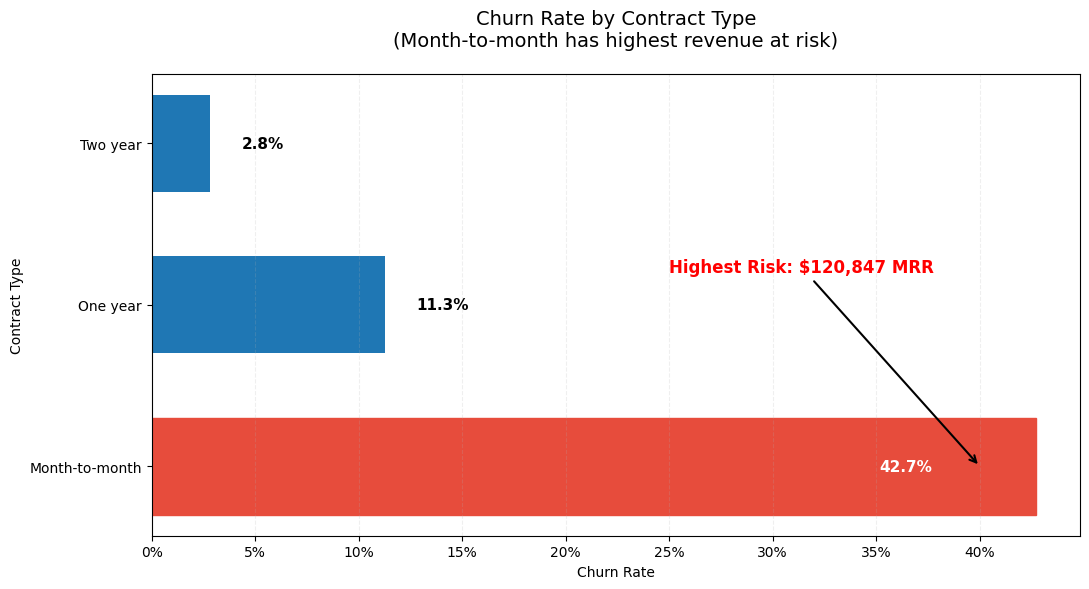

In [15]:
## calculating MRR for churned customers of month to month subscription
revenue_at_risk = df[(df['Churn_Flag'] == 1) & (df['Contract'] == 'Month-to-month')]['MRR'].sum()

# Calculating Churn rate for contract types and sorting
contract_churn = df.groupby('Contract')['Churn_Flag'].mean().reset_index(name='Churn_Rate')
contract_churn = contract_churn.sort_values("Churn_Rate", ascending=False)

plt.figure(figsize=(11,6))
bars = plt.barh(y=contract_churn["Contract"], width=contract_churn["Churn_Rate"], height=0.6)

# highlighting highest risk bar
bars[0].set_color('#e74c3c')

# Add percentage labels on bars
for i, v in enumerate(contract_churn['Churn_Rate']):
    if v < 0.35:          # For smaller bars (Two year & One year)
        plt.text(v + 0.015, i, f"{v:.1%}", va='center', fontsize=11, fontweight='bold')
    else:                 # For the long bar (Month-to-month)
        plt.text(v - 0.05, i, f"{v:.1%}", va='center', ha='right', 
                 fontsize=11, fontweight='bold', color='white')

plt.annotate("Highest Risk: $120,847 MRR", 
             xy=(0.40, 0), 
             xytext=(0.25, 1.2),
             arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
             fontsize=12, 
             fontweight='bold',
             color='red')

# Format X-axis as percentages
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.title("Churn Rate by Contract Type\n(Month-to-month has highest revenue at risk)", fontsize=14, pad=20)
plt.xlabel("Churn Rate")
plt.ylabel("Contract Type")
plt.grid(axis='x', alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

## Saving Data for PowerBI

In [16]:
df.to_csv('../data/processed/cleaned_saas_churn.csv', index=False)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   MonthsSubscribed  7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

## Star Schema Architecture
- **Fact Table**: Will contain the unique customerID, the integer foreign keys for your dimensions, and the quantitative metrics (MRR, LTV, MonthsSubscribed, Churn_Flag).

- **Dim_Contract**: Will contain unique subscription types.

- **Dim_Payment**: Will contain unique payment methods.

- **Dim_Customer**: Will contain static demographic data (gender, SeniorCitizen, Partner, Dependents).

### Contract Dimension Table

In [18]:
# Create dimension table for Contract
dim_contract = pd.DataFrame({
    'Contract': df['Contract'].unique()
})

# Add sequential Contract_ID starting from 1
dim_contract['Contract_ID'] = range(1, len(dim_contract) + 1)

# Reorder columns
dim_contract = dim_contract[['Contract_ID', 'Contract']]

# Save to processed folder
dim_contract.to_csv('../data/processed/dim_contract.csv', index=False)

dim_contract

,Contract_ID,Contract
0,1,Month-to-month
1,2,One year
2,3,Two year


In [19]:
# Mapping Contract_ID back to the main dataframe
fact_table = df.merge(dim_contract, on='Contract', how='left')

# Dropping the original text column
fact_table = fact_table.drop(columns=['Contract'])

print(fact_table.head())

   customerID  gender  SeniorCitizen Partner Dependents  MonthsSubscribed  \
0  7590-VHVEG  Female              0     Yes         No                 1   
1  5575-GNVDE    Male              0      No         No                34   
2  3668-QPYBK    Male              0      No         No                 2   
3  7795-CFOCW    Male              0      No         No                45   
4  9237-HQITU  Female              0      No         No                 2   

  PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0           No  No phone service             DSL             No  ...   
1          Yes                No             DSL            Yes  ...   
2          Yes                No             DSL            Yes  ...   
3           No  No phone service             DSL            Yes  ...   
4          Yes                No     Fiber optic             No  ...   

  StreamingTV StreamingMovies PaperlessBilling              PaymentMethod  \
0          No              

### Payment Dimension Table

In [20]:
# Create dimension table for Payment Methods
dim_payment = pd.DataFrame({
    'PaymentMethod': df['PaymentMethod'].unique()
})

# Add sequential Payment_ID starting from 1
dim_payment['Payment_ID'] = range(1, len(dim_payment) + 1)

# Reorder columns
dim_payment = dim_payment[['Payment_ID', 'PaymentMethod']]

# Save to processed folder
dim_payment.to_csv('../data/processed/dim_payment.csv', index=False)

dim_payment

,Payment_ID,PaymentMethod
0,1,Electronic check
1,2,Mailed check
2,3,Bank transfer (automatic)
3,4,Credit card (automatic)


In [21]:
# Mapping Payment_ID back to the main fact table
fact_table = fact_table.merge(dim_payment, on='PaymentMethod', how='left')

# Dropping the original text column
fact_table = fact_table.drop(columns=['PaymentMethod'])

print(fact_table.head())

   customerID  gender  SeniorCitizen Partner Dependents  MonthsSubscribed  \
0  7590-VHVEG  Female              0     Yes         No                 1   
1  5575-GNVDE    Male              0      No         No                34   
2  3668-QPYBK    Male              0      No         No                 2   
3  7795-CFOCW    Male              0      No         No                45   
4  9237-HQITU  Female              0      No         No                 2   

  PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0           No  No phone service             DSL             No  ...   
1          Yes                No             DSL            Yes  ...   
2          Yes                No             DSL            Yes  ...   
3           No  No phone service             DSL            Yes  ...   
4          Yes                No     Fiber optic             No  ...   

  StreamingTV StreamingMovies PaperlessBilling    MRR      LTV Churn  \
0          No              No   